In [40]:
import pandas as pd
import numpy as np
import re

In [41]:
# Load all years
years = [2015, 2016, 2017, 2018, 2019, 2023, 2024]

cps_list, act_list, resp_list = [], [], []
for yr in years:
    cps_list.append(pd.read_csv(f"../data/atuscps_{yr}.dat"))
    act_list.append(pd.read_csv(f"../data/atussum_{yr}.dat"))
    resp_list.append(pd.read_csv(f"../data/atusresp_{yr}.dat"))

# Stack years together (use shared columns only in case they differ across years)
shared_cps_cols = list(set.intersection(*[set(d.columns) for d in cps_list]))
cps = pd.concat([d[shared_cps_cols] for d in cps_list], ignore_index=True)

shared_act_cols = list(set.intersection(*[set(d.columns) for d in act_list]))
act_sum = pd.concat([d[shared_act_cols] for d in act_list], ignore_index=True)

shared_resp_cols = list(set.intersection(*[set(d.columns) for d in resp_list]))
resp = pd.concat([d[shared_resp_cols] for d in resp_list], ignore_index=True)

print("CPS:", cps.shape)
print("Activity Summary:", act_sum.shape)
print("Respondent:", resp.shape)

CPS: (453448, 364)
Activity Summary: (66866, 345)
Respondent: (66866, 174)


In [42]:
# --- Pull occupation from CPS (keep one row per person) ---
cps_person = cps[cps["TULINENO"] == 1][["TUCASEID", "PRMJOCC1"]].copy()

# --- Pull diary date and detailed occupation from respondent file ---
resp_vars = resp[["TUCASEID", "TUDIARYDATE", "TRDTOCC1"]].copy()

# --- Merge activity summary with CPS occupation and respondent vars ---
df = act_sum.merge(cps_person, on="TUCASEID", how="left")
df = df.merge(resp_vars, on="TUCASEID", how="left")

# --- Filter to ages 19-26 ---
df = df[(df["TEAGE"] >= 19) & (df["TEAGE"] <= 26)].copy()

# --- Classify groups ---
# TESCHENR: 1 = enrolled in school, 2 = not enrolled
# TESCHLVL: 2 = college/university
# PEEDUCA: >= 43 means bachelor's degree or higher
# TELFS: 1 = employed full-time, 2 = employed part-time

conditions = {
    "Undergrad": (df["TESCHENR"] == 1) & (df["TESCHLVL"] == 2) & (df["PEEDUCA"] < 43),
    "Graduate": (df["TESCHENR"] == 1) & (df["TESCHLVL"] == 2) & (df["PEEDUCA"] >= 43),
    "Employed": (df["TESCHENR"] == 2) & (df["TELFS"] == 1)  & (df["PEEDUCA"] >= 43),
}

df["group"] = "Other"
for label, mask in conditions.items():
    df.loc[mask, "group"] = label

# --- Drop anyone who didn't fit a group ---
df = df[df["group"] != "Other"].copy()

# --- Collect activity columns (all start with "t" followed by digits) ---
activity_cols = [c for c in df.columns if c.startswith("t") and c[1:2].isdigit()]

# --- Build final dataset ---
analysis_df = df[["TUCASEID", "group", "TEAGE", "TESEX", "PRMJOCC1", "TRDTOCC1", "TUDIARYDAY", "TUDIARYDATE"] + activity_cols].copy()

print(f"Final shape: {analysis_df.shape}")
print(f"\nGroup counts:")
print(analysis_df["group"].value_counts())

print(f"\nSex counts:")
print(analysis_df["TESEX"].value_counts())

analysis_df.head()

Final shape: (2067, 329)

Group counts:
group
Undergrad    1044
Employed      803
Graduate      220
Name: count, dtype: int64

Sex counts:
TESEX
2    1133
1     934
Name: count, dtype: int64


,TUCASEID,group,TEAGE,TESEX,PRMJOCC1,TRDTOCC1,TUDIARYDAY,TUDIARYDATE,t180603,t180208,...,t120308,t060301,t020303,t159999,t010102,t130227,t060202,t070104,t160105,t010301
27,20150101150794,Undergrad,19,2,3,-1,6,20150130,0,0,...,0,0,0,0,0,0,0,0,0,0
45,20150101150989,Graduate,23,1,2,8,1,20150125,0,0,...,0,0,0,0,0,0,0,0,0,0
82,20150101151505,Undergrad,19,1,-1,-1,1,20150125,0,0,...,0,160,0,0,0,0,0,0,0,0
85,20150101151539,Employed,25,2,1,1,4,20150128,0,0,...,40,0,0,0,0,0,0,0,0,0
127,20150101152146,Undergrad,19,2,-1,-1,7,20150131,0,0,...,0,690,0,0,0,0,0,0,0,0


In [43]:
analysis_df.columns

Index(['TUCASEID', 'group', 'TEAGE', 'TESEX', 'PRMJOCC1', 'TRDTOCC1',
       'TUDIARYDAY', 'TUDIARYDATE', 't180603', 't180208',
       ...
       't120308', 't060301', 't020303', 't159999', 't010102', 't130227',
       't060202', 't070104', 't160105', 't010301'],
      dtype='object', length=329)

In [44]:
# Group all time columns into broad activity buckets

# All ATUS time columns (6-digit codes like t010101, t050101, etc.)
activity_cols = [c for c in analysis_df.columns if re.match(r'^t\d{6}$', c)]

def classify_activity(col):
    """Map a 6-digit ATUS column (e.g. 't060101') to one of 6 broad buckets."""
    major = col[1:3]   # e.g. '06'
    tier2 = col[3:5]   # e.g. '01'
    tier3 = col[5:7]   # e.g. '01'

    # --- work: employment + degree education ---
    if major == '05':
        return 'work'
    if major == '06':
        # Personal interest / extracurricular → leisure_rec
        if (tier2 == '01' and tier3 == '02'):       # class for personal interest
            return 'leisure_rec'
        if (tier2 == '02'):                          # extracurricular activities
            return 'leisure_rec'
        if (tier2 == '03' and tier3 == '02'):       # homework for personal interest
            return 'leisure_rec'
        if (tier2 == '04' and tier3 == '02'):       # admin for personal interest
            return 'leisure_rec'
        return 'work'  # all other education (degree, admin, nec)

    # --- personal_care: sleep, grooming, health, eating, medical/personal svcs ---
    if major == '01':
        return 'personal_care'
    if major == '11':
        return 'personal_care'
    if major == '08' and tier2 in ('04', '05'):  # medical + personal care services
        return 'personal_care'

    # --- domestic_cares: household, shopping, financial/legal/vet svcs, hh services ---
    if major == '02':
        return 'domestic_cares'
    if major == '07':
        return 'domestic_cares'
    if major == '08':  # remaining 08 (childcare, financial, legal, real estate, vet, security, nec)
        return 'domestic_cares'
    if major == '09':
        return 'domestic_cares'

    # --- community_cares: caregiving, civic, religious, volunteer ---
    if major == '03':
        return 'community_cares'
    if major == '04':
        return 'community_cares'
    if major == '10':
        return 'community_cares'
    if major == '14':
        return 'community_cares'
    if major == '15':
        return 'community_cares'

    # --- leisure_rec: socializing, sports, personal enrichment, personal phone calls ---
    if major == '12':
        return 'leisure_rec'
    if major == '13':
        return 'leisure_rec'

    # --- telephone calls: split by who you're calling ---
    if major == '16':
        if tier2 == '01' and tier3 in ('01', '02'):  # family, friends
            return 'leisure_rec'
        if tier2 == '01' and tier3 == '03':           # education providers
            return 'community_cares'
        if tier2 == '01' and tier3 in ('04', '05', '06', '07'):  # sales, prof, hh svc, childcare
            return 'domestic_cares'
        if tier2 == '01' and tier3 == '08':           # government
            return 'community_cares'
        if tier2 == '01' and tier3 == '99':           # nec
            return 'leisure_rec'
        # tier2 02 (waiting), 99 (nec)
        return 'leisure_rec'

    # --- traveling: split by purpose ---
    if major == '18':
        if tier2 == '01':  return 'personal_care'      # travel for personal care
        if tier2 == '02':  return 'domestic_cares'      # travel for household
        if tier2 == '03':  return 'community_cares'     # travel for HH members
        if tier2 == '04':  return 'community_cares'     # travel for nonHH members
        if tier2 == '05':  return 'work'                # travel for work
        if tier2 == '06':                               # travel for education
            if tier3 == '02': return 'leisure_rec'      #   extracurricular
            return 'work'                               #   degree/admin/other
        if tier2 == '07':  return 'domestic_cares'      # travel for shopping
        if tier2 == '08':                               # travel for prof services
            if tier3 in ('04', '05'): return 'personal_care'  # medical, personal care
            return 'domestic_cares'                     # financial, legal, vet, etc.
        if tier2 == '09':  return 'domestic_cares'      # travel for hh services
        if tier2 == '10':  return 'community_cares'     # travel for govt/civic
        if tier2 == '11':  return 'personal_care'       # travel for eating
        if tier2 == '12':  return 'leisure_rec'         # travel for socializing
        if tier2 == '13':  return 'leisure_rec'         # travel for sports
        if tier2 == '14':  return 'community_cares'     # travel for religious
        if tier2 == '15':  return 'community_cares'     # travel for volunteer
        if tier2 == '16':  return 'leisure_rec'         # travel for phone calls
        if tier2 == '18':  return 'domestic_cares'      # security for traveling
        if tier2 == '99':  return 'domestic_cares'      # travel nec

    # --- data_codes ---
    if major == '50':
        return 'data_codes'

    return 'data_codes'  # fallback (should not happen)

# Classify every column and group
bucket_map = {}  # {bucket_name: [list of t-columns]}
for col in activity_cols:
    bucket = classify_activity(col)
    bucket_map.setdefault(bucket, []).append(col)

# The 6 broad activity buckets
activity_buckets = ['work', 'personal_care', 'domestic_cares', 'leisure_rec', 'community_cares', 'data_codes']

# Build final_df
final_df = analysis_df[['TUCASEID', 'group', 'TEAGE', 'TESEX', 'PRMJOCC1', 'TRDTOCC1']].copy()

# Year from TUCASEID
final_df['year'] = final_df['TUCASEID'].astype(str).str[:4].astype(int)

# Weekend vs Weekday
final_df['is_weekend'] = analysis_df['TUDIARYDAY'].isin([1, 7]).astype(int)

# Break vs Semester
diary_month = (analysis_df['TUDIARYDATE'] // 100) % 100
diary_day = analysis_df['TUDIARYDATE'] % 100
is_summer = diary_month.isin([6, 7, 8]) | ((diary_month == 5) & (diary_day >= 15))
is_winter_dec = (diary_month == 12) & (diary_day >= 15)
is_winter_jan = (diary_month == 1) & (diary_day <= 14)
final_df['is_break'] = (is_summer | is_winter_dec | is_winter_jan).astype(int)

# Sum minutes into each bucket
for bucket in activity_buckets:
    cols = bucket_map.get(bucket, [])
    final_df[bucket] = analysis_df[cols].sum(axis=1) if cols else 0

# Verify: total minutes per person should equal sum of all activity columns
total_from_buckets = final_df[activity_buckets].sum(axis=1)
total_from_raw = analysis_df[activity_cols].sum(axis=1)
assert (total_from_buckets == total_from_raw).all(), 'Bucket totals do not match raw totals!'

print(f'Activity columns classified: {len(activity_cols)}')
for b in activity_buckets:
    print(f'  {b}: {len(bucket_map.get(b, []))} columns, {final_df[b].sum()/60:.0f} total hours')
print(f'\nYear counts:\n{final_df["year"].value_counts()}')
print(f'\nWeekend vs Weekday:\n{final_df["is_weekend"].value_counts().rename({0: "Weekday", 1: "Weekend"})}')
print(f'\nBreak vs Semester:\n{final_df["is_break"].value_counts().rename({0: "Semester", 1: "Break"})}')
print(f'\nGroup counts:\n{final_df["group"].value_counts()}')
final_df.head()

Activity columns classified: 321
  work: 26 columns, 10114 total hours
  personal_care: 18 columns, 23612 total hours
  domestic_cares: 82 columns, 3801 total hours
  leisure_rec: 85 columns, 10527 total hours
  community_cares: 105 columns, 1148 total hours
  data_codes: 5 columns, 335 total hours

Year counts:
year
2015    346
2016    332
2019    292
2017    280
2018    280
2024    271
2023    266
Name: count, dtype: int64

Weekend vs Weekday:
is_weekend
Weekend    1047
Weekday    1020
Name: count, dtype: int64

Break vs Semester:
is_break
Semester    1336
Break        731
Name: count, dtype: int64

Group counts:
group
Undergrad    1044
Employed      803
Graduate      220
Name: count, dtype: int64


,TUCASEID,group,TEAGE,TESEX,PRMJOCC1,TRDTOCC1,year,is_weekend,is_break,work,personal_care,domestic_cares,leisure_rec,community_cares,data_codes
27,20150101150794,Undergrad,19,2,3,-1,2015,0,0,60,720,150,450,0,60
45,20150101150989,Graduate,23,1,2,8,2015,1,0,120,565,260,495,0,0
82,20150101151505,Undergrad,19,1,-1,-1,2015,1,0,160,770,30,460,0,20
85,20150101151539,Employed,25,2,1,1,2015,0,0,605,585,0,250,0,0
127,20150101152146,Undergrad,19,2,-1,-1,2015,1,0,690,665,60,25,0,0


In [45]:
# --- Check ambiguous transition dates (undergrad + grad only) ---
student_mask = analysis_df["group"].isin(["Undergrad", "Graduate"])
student_df = analysis_df[student_mask]

diary_month = (student_df["TUDIARYDATE"] // 100) % 100
diary_day = student_df["TUDIARYDATE"] % 100

ambiguous = (
    ((diary_month == 5) & (diary_day <= 14)) |                        # May 1-14
    ((diary_month == 8) & (diary_day >= 15)) | (diary_month == 9) |   # Aug 15 - Sep 30
    ((diary_month == 1) & (diary_day >= 5) & (diary_day <= 14)) |     # Jan 5-14
    ((diary_month == 1) & (diary_day >= 15)) | ((diary_month == 2) & (diary_day <= 2)) |  # Jan 15 - Feb 2
    ((diary_month == 12) & (diary_day >= 13) & (diary_day <= 20))     # Dec 13-20
)

n_ambiguous = ambiguous.sum()
n_students = len(student_df)
n_total = len(analysis_df)

print(f"Ambiguous transition-period data points (Undergrad + Grad only): {n_ambiguous}")
print(f"  As % of all data:              {n_ambiguous / n_total:.3f} ({n_ambiguous / n_total * 100:.1f}%)")
print(f"  As % of undergrad+grad only:   {n_ambiguous / n_students:.3f} ({n_ambiguous / n_students * 100:.1f}%)")

# Breakdown by period
periods = {
    "May 1-14 (end of spring)": (diary_month == 5) & (diary_day <= 14),
    "Aug 15 - Sep 30 (fall start)": ((diary_month == 8) & (diary_day >= 15)) | (diary_month == 9),
    "Jan 5-14 (pre-spring, in break)": (diary_month == 1) & (diary_day >= 5) & (diary_day <= 14),
    "Jan 15 - Feb 2 (spring start)": ((diary_month == 1) & (diary_day >= 15)) | ((diary_month == 2) & (diary_day <= 2)),
    "Dec 13-20 (finals/break edge)": (diary_month == 12) & (diary_day >= 13) & (diary_day <= 20),
}

print(f"\nBreakdown (Undergrad + Grad):")
print(f"  {'Period':<40} {'n':>5}  {'% of all':>8}  {'% of students':>13}")
print(f"  {'-'*40} {'-'*5}  {'-'*8}  {'-'*13}")
for label, mask in periods.items():
    n = mask.sum()
    print(f"  {label:<40} {n:>5}  {n/n_total*100:>7.1f}%  {n/n_students*100:>12.1f}%")

Ambiguous transition-period data points (Undergrad + Grad only): 351
  As % of all data:              0.170 (17.0%)
  As % of undergrad+grad only:   0.278 (27.8%)

Breakdown (Undergrad + Grad):
  Period                                       n  % of all  % of students
  ---------------------------------------- -----  --------  -------------
  May 1-14 (end of spring)                    43      2.1%           3.4%
  Aug 15 - Sep 30 (fall start)               133      6.4%          10.5%
  Jan 5-14 (pre-spring, in break)             41      2.0%           3.2%
  Jan 15 - Feb 2 (spring start)               95      4.6%           7.5%
  Dec 13-20 (finals/break edge)               39      1.9%           3.1%


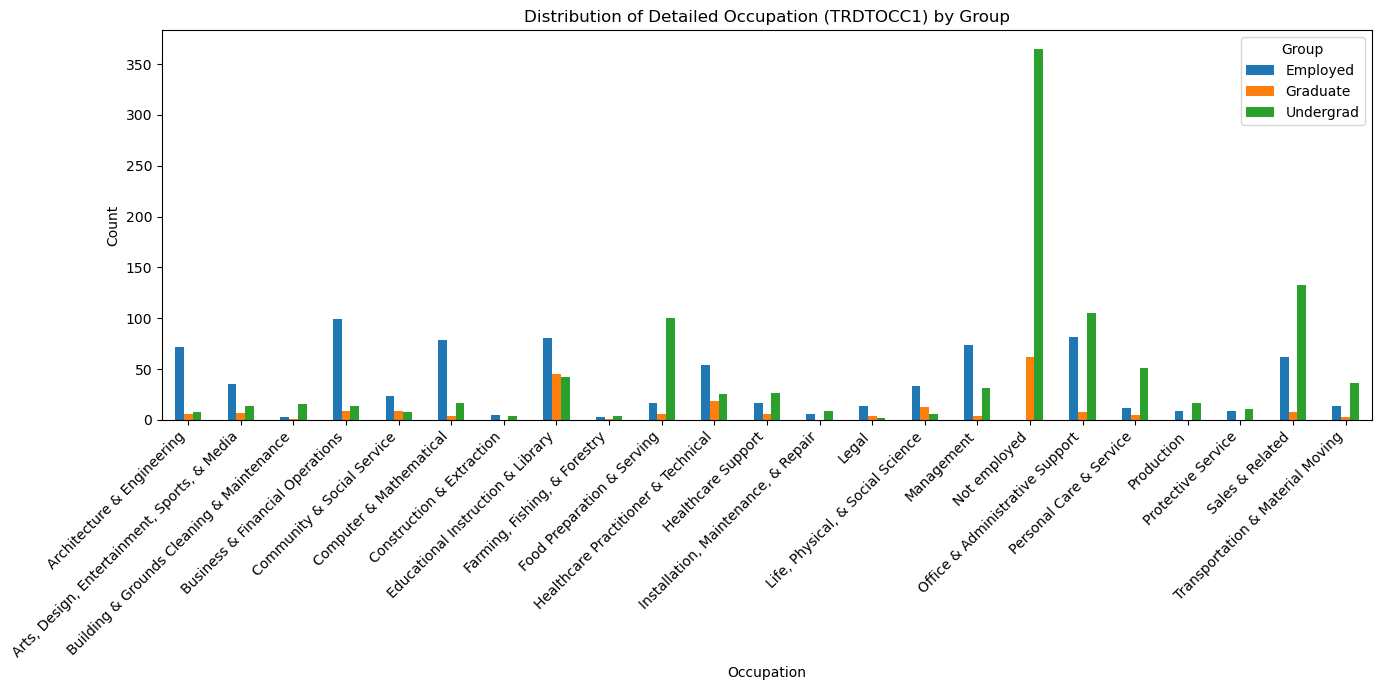

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Detailed occupation code labels (TRDTOCC1)
occ_detail_labels = {
    -1: "Not employed",
    1: "Management",
    2: "Business & Financial Operations",
    3: "Computer & Mathematical",
    4: "Architecture & Engineering",
    5: "Life, Physical, & Social Science",
    6: "Community & Social Service",
    7: "Legal",
    8: "Educational Instruction & Library",
    9: "Arts, Design, Entertainment, Sports, & Media",
    10: "Healthcare Practitioner & Technical",
    11: "Healthcare Support",
    12: "Protective Service",
    13: "Food Preparation & Serving",
    14: "Building & Grounds Cleaning & Maintenance",
    15: "Personal Care & Service",
    16: "Sales & Related",
    17: "Office & Administrative Support",
    18: "Farming, Fishing, & Forestry",
    19: "Construction & Extraction",
    20: "Installation, Maintenance, & Repair",
    21: "Production",
    22: "Transportation & Material Moving"
}

# Map codes to labels
plot_df = final_df.copy()
plot_df["Occupation"] = plot_df["TRDTOCC1"].map(occ_detail_labels).fillna("Unknown")

fig, ax = plt.subplots(figsize=(14, 7))
occ_counts = plot_df.groupby(["group", "Occupation"]).size().unstack(fill_value=0)
occ_counts.T.plot(kind="bar", ax=ax)
ax.set_xlabel("Occupation")
ax.set_ylabel("Count")
ax.set_title("Distribution of Detailed Occupation (TRDTOCC1) by Group")
ax.legend(title="Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

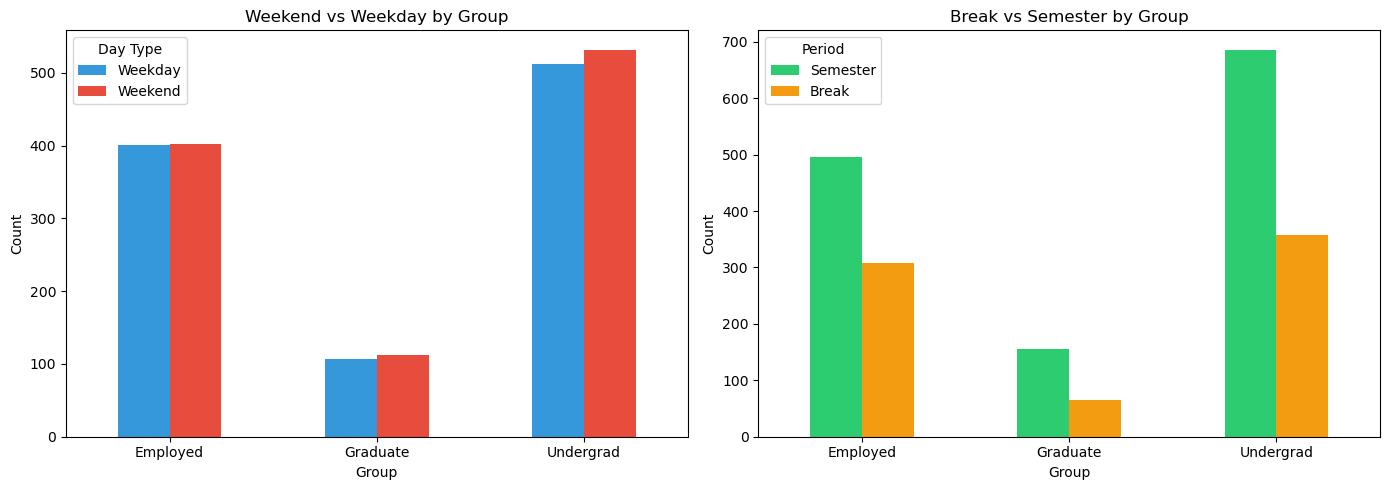

Weekend vs Weekday by Group:
is_weekend  Weekday  Weekend   All
group                             
Employed        401      402   803
Graduate        107      113   220
Undergrad       512      532  1044
All            1020     1047  2067

Break vs Semester by Group:
is_break   Break  Semester   All
group                           
Employed     308       495   803
Graduate      65       155   220
Undergrad    358       686  1044
All          731      1336  2067


In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekend vs Weekday by group
weekend_counts = final_df.groupby(["group", "is_weekend"]).size().unstack(fill_value=0)
weekend_counts.columns = ["Weekday", "Weekend"]
weekend_counts.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"])
axes[0].set_title("Weekend vs Weekday by Group")
axes[0].set_xlabel("Group")
axes[0].set_ylabel("Count")
axes[0].legend(title="Day Type")
axes[0].tick_params(axis='x', rotation=0)

# Break vs Semester by group
break_counts = final_df.groupby(["group", "is_break"]).size().unstack(fill_value=0)
break_counts.columns = ["Semester", "Break"]
break_counts.plot(kind="bar", ax=axes[1], color=["#2ecc71", "#f39c12"])
axes[1].set_title("Break vs Semester by Group")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Count")
axes[1].legend(title="Period")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Crosstab summaries
print("Weekend vs Weekday by Group:")
print(pd.crosstab(final_df["group"], final_df["is_weekend"].map({0: "Weekday", 1: "Weekend"}), margins=True))
print(f"\nBreak vs Semester by Group:")
print(pd.crosstab(final_df["group"], final_df["is_break"].map({0: "Semester", 1: "Break"}), margins=True))

In [48]:
final_df.columns

Index(['TUCASEID', 'group', 'TEAGE', 'TESEX', 'PRMJOCC1', 'TRDTOCC1', 'year',
       'is_weekend', 'is_break', 'work', 'personal_care', 'domestic_cares',
       'leisure_rec', 'community_cares', 'data_codes'],
      dtype='object')

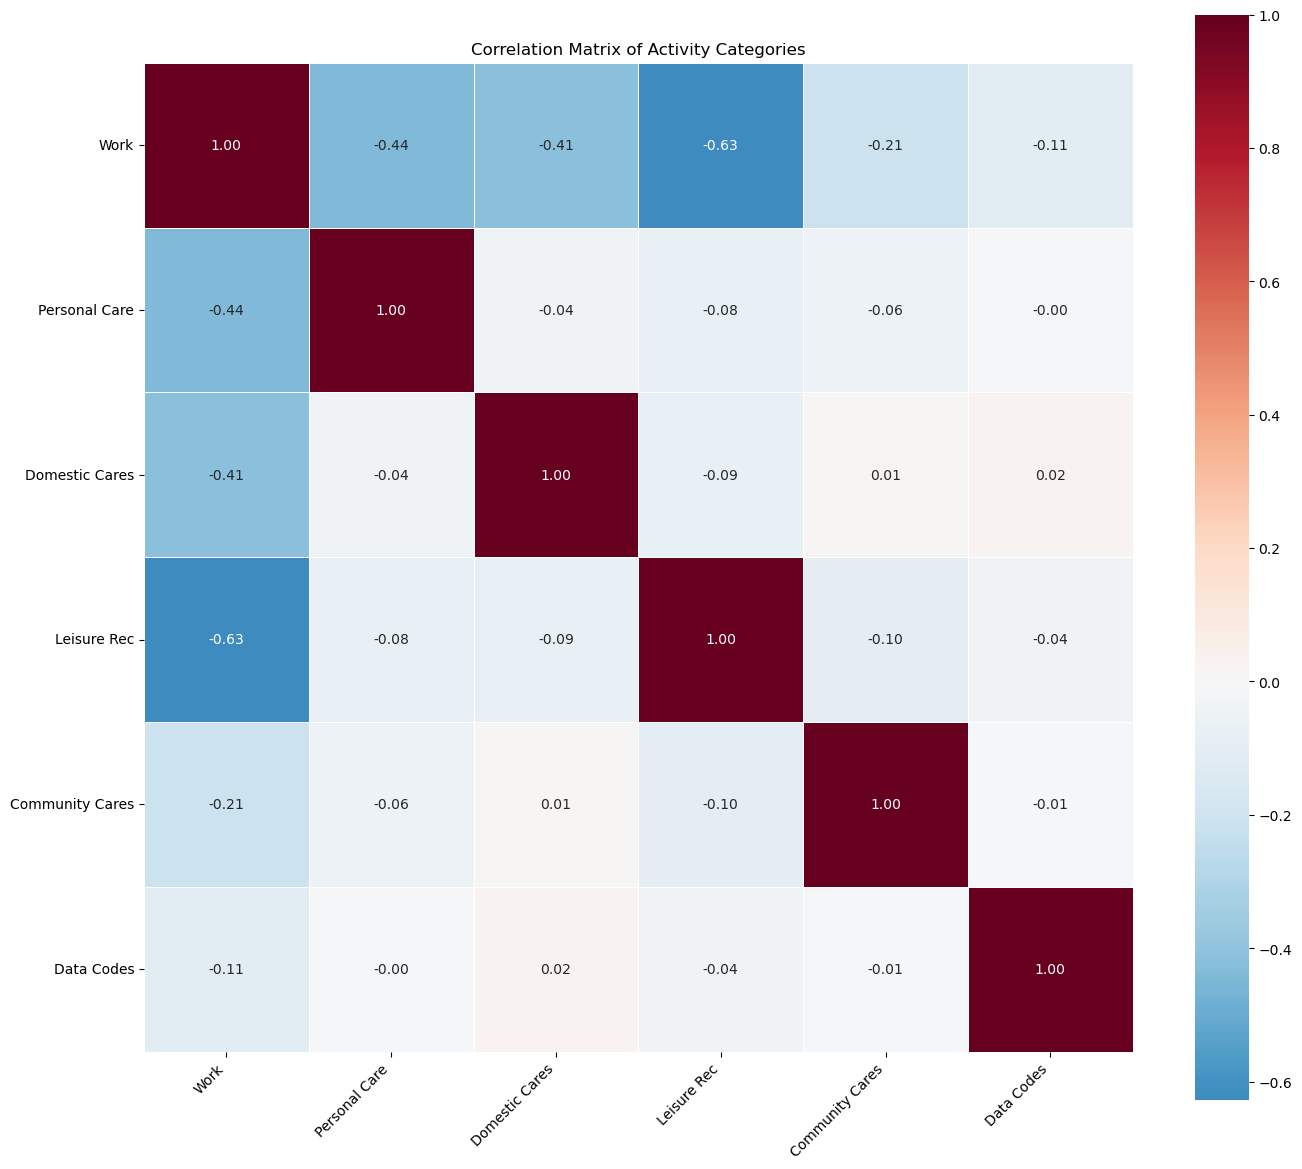

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Activity category columns (exclude ID, group, demographic, and temporal vars)
non_activity_cols = {"TUCASEID", "group", "TEAGE", "TESEX", "PRMJOCC1", "TRDTOCC1",
                     "year", "is_weekend", "is_break"}
activity_categories = [c for c in final_df.columns if c not in non_activity_cols]

corr = final_df[activity_categories].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=[c.replace("_", " ").title() for c in corr.columns],
            yticklabels=[c.replace("_", " ").title() for c in corr.index])
ax.set_title("Correlation Matrix of Activity Categories")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Multinomial Logistic Regressions (with and without activity)

In [50]:
# --- Model 1: Background variables only (no activities) ---
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

model_df = final_df.copy()
y = model_df["group"]

# Background features only
bg_features = ["TESEX", "year", "is_weekend", "is_break"]
X_bg = model_df[bg_features].astype(float)

scaler_bg = StandardScaler()
X_bg_scaled = pd.DataFrame(scaler_bg.fit_transform(X_bg), columns=X_bg.columns, index=X_bg.index)
X_bg_const = sm.add_constant(X_bg_scaled)

mnlogit_bg = sm.MNLogit(y, X_bg_const)
result_bg = mnlogit_bg.fit(method='lbfgs', maxiter=500, disp=True)

print("=== Model 1: Background Only ===")
print(f"Log-Likelihood: {result_bg.llf:.2f}")
print(f"Pseudo R²: {result_bg.prsquared:.4f}")
print(f"AIC: {result_bg.aic:.2f}")
print(f"BIC: {result_bg.bic:.2f}")
print(f"\nFeatures: {bg_features}")
print(result_bg.summary())

=== Model 1: Background Only ===
Log-Likelihood: -1945.46
Pseudo R²: 0.0100
AIC: 3910.92
BIC: 3967.26

Features: ['TESEX', 'year', 'is_weekend', 'is_break']
                          MNLogit Regression Results                          
Dep. Variable:                  group   No. Observations:                 2067
Model:                        MNLogit   Df Residuals:                     2057
Method:                           MLE   Df Model:                            8
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                 0.01003
Time:                        16:25:17   Log-Likelihood:                -1945.5
converged:                       True   LL-Null:                       -1965.2
Covariance Type:            nonrobust   LLR p-value:                 4.084e-06
 group=Graduate       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.2972      0.077    -1

In [51]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# --- Prepare modeling dataframe ---
model_df = final_df.copy()

# Build feature matrix: sex, year, weekend, break, and activity buckets
X = model_df[['TESEX', 'year', 'is_weekend', 'is_break'] + activity_buckets].astype(float)

# Encode the target
y = model_df['group']

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')
print(f'\nFeatures: {list(X.columns)}')

Feature matrix shape: (2067, 10)
Target distribution:
group
Undergrad    1044
Employed      803
Graduate      220
Name: count, dtype: int64

Features: ['TESEX', 'year', 'is_weekend', 'is_break', 'work', 'personal_care', 'domestic_cares', 'leisure_rec', 'community_cares', 'data_codes']


In [52]:
# --- Multinomial Logistic Regression with statsmodels (for coefficients & p-values) ---

# Standardize continuous features for numerical stability
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_const = sm.add_constant(X_scaled)

# Fit multinomial logit (reference category = alphabetically first = "Employed")
mnlogit_model = sm.MNLogit(y, X_const)
result = mnlogit_model.fit(method='lbfgs', maxiter=500, disp=True)

print(result.summary())

                          MNLogit Regression Results                          
Dep. Variable:                  group   No. Observations:                 2067
Model:                        MNLogit   Df Residuals:                     2045
Method:                           MLE   Df Model:                           20
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                 0.02194
Time:                        16:25:17   Log-Likelihood:                -1922.1
converged:                       True   LL-Null:                       -1965.2
Covariance Type:            nonrobust   LLR p-value:                 3.353e-10
 group=Graduate       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.3232      0.080    -16.500      0.000      -1.480      -1.166
TESEX               0.1116      0.079      1.417      0.157      -0.043       0.266
year               -0.0686      

In [53]:
# --- Likelihood Ratio Test: Does adding activities improve the model? ---
from scipy import stats

ll_restricted = result_bg.llf   # background-only model
ll_full = result.llf             # full model with activities

# LRT statistic = 2 * (LL_full - LL_restricted)
lrt_stat = 2 * (ll_full - ll_restricted)

# Degrees of freedom = difference in number of parameters
df_diff = result.df_model - result_bg.df_model

# p-value from chi-squared distribution
lrt_pvalue = stats.chi2.sf(lrt_stat, df_diff)

print("=== Model Comparison ===")
print(f"\nModel 1 (Background only):  LL = {ll_restricted:.2f}, Pseudo R² = {result_bg.prsquared:.4f}, AIC = {result_bg.aic:.2f}, BIC = {result_bg.bic:.2f}")
print(f"Model 2 (With activities):  LL = {ll_full:.2f}, Pseudo R² = {result.prsquared:.4f}, AIC = {result.aic:.2f}, BIC = {result.bic:.2f}")
print(f"\n--- Likelihood Ratio Test ---")
print(f"LRT statistic: {lrt_stat:.2f}")
print(f"Degrees of freedom: {df_diff}")
print(f"p-value: {lrt_pvalue:.2e}")
print(f"\nConclusion: {'Activities significantly improve the model (p < 0.05)' if lrt_pvalue < 0.05 else 'Activities do NOT significantly improve the model (p >= 0.05)'}")

=== Model Comparison ===

Model 1 (Background only):  LL = -1945.46, Pseudo R² = 0.0100, AIC = 3910.92, BIC = 3967.26
Model 2 (With activities):  LL = -1922.06, Pseudo R² = 0.0219, AIC = 3888.12, BIC = 4012.07

--- Likelihood Ratio Test ---
LRT statistic: 46.80
Degrees of freedom: 12.0
p-value: 5.05e-06

Conclusion: Activities significantly improve the model (p < 0.05)


In [54]:
# --- All coefficients with p-values as a clean dataframe ---
all_coefs = []
for group_label in result.params.columns:
    for feat in result.params.index:
        all_coefs.append({
            "group_vs_Employed": group_label,
            "feature": feat,
            "coefficient": result.params.loc[feat, group_label],
            "std_err": result.bse.loc[feat, group_label],
            "z_score": result.tvalues.loc[feat, group_label],
            "p_value": result.pvalues.loc[feat, group_label],
        })

all_coefs_df = pd.DataFrame(all_coefs)
print(f"Total coefficients: {len(all_coefs_df)}")
all_coefs_df

Total coefficients: 22


,group_vs_Employed,feature,coefficient,std_err,z_score,p_value
0,0,const,-1.323218,0.080195,-16.500031,3.667018e-61
1,0,TESEX,0.111557,0.078742,1.416749,1.565562e-01
2,0,year,-0.068611,0.075697,-0.906393,3.647278e-01
3,0,is_weekend,0.098054,0.086384,1.135093,2.563364e-01
4,0,is_break,-0.169864,0.079558,-2.135096,3.275314e-02
5,0,work,2.357963,2.237853,1.053672,2.920332e-01
6,0,personal_care,1.236257,1.213464,1.018783,3.083061e-01
7,0,domestic_cares,1.159573,1.107918,1.046624,2.952731e-01
8,0,leisure_rec,1.572940,1.684124,0.933981,3.503136e-01
9,0,community_cares,0.603476,0.718348,0.840089,4.008586e-01


In [55]:
# --- Extract significant predictors (p < 0.05) ---
import matplotlib.pyplot as plt

params = result.params
pvalues = result.pvalues

# params/pvalues have shape (n_features, K-1) — one column per non-reference group
group_labels = params.columns.tolist()

sig_results = []
for col_idx, group_label in enumerate(group_labels):
    for feat in params.index:
        pval = pvalues.loc[feat, group_label]
        if pval < 0.05 and feat != "const":
            sig_results.append({
                "group_vs_reference": group_label,
                "feature": feat,
                "coefficient": params.loc[feat, group_label],
                "p_value": pval
            })

sig_df = pd.DataFrame(sig_results).sort_values("p_value")
print(f"Significant predictors (p < 0.05): {len(sig_df)}")
sig_df

Significant predictors (p < 0.05): 3


,group_vs_reference,feature,coefficient,p_value
1,1,year,-0.239108,6.039554e-07
2,1,data_codes,0.233972,1.268493e-02
0,0,is_break,-0.169864,3.275314e-02


# Multivariate Regression: Activity Time by Group and Background

In [56]:
# --- Multivariate OLS: each activity bucket ~ group + background ---
import statsmodels.api as sm

model_df = final_df.copy()

# Create dummy variables for group (reference = Employed)
group_dummies = pd.get_dummies(model_df['group'], drop_first=False)
group_dummies = group_dummies[['Graduate', 'Undergrad']]  # Employed is reference

# Predictor matrix: group dummies + background variables
X = pd.concat([group_dummies, model_df[['TESEX', 'year', 'is_weekend', 'is_break']]], axis=1).astype(float)
X = sm.add_constant(X)

# Activity bucket outcomes
Y = model_df[activity_buckets].astype(float)

print(f'Predictors: {list(X.columns)}')
print(f'Outcomes ({len(activity_buckets)}): {activity_buckets}')
print(f'N = {len(X)}')

# Fit OLS for each bucket and collect results
results = {}
summary_rows = []

for activity in activity_buckets:
    model = sm.OLS(Y[activity], X).fit()
    results[activity] = model
    for predictor in ['Graduate', 'Undergrad', 'TESEX', 'year', 'is_weekend', 'is_break']:
        summary_rows.append({
            'activity': activity,
            'predictor': predictor,
            'coefficient': model.params[predictor],
            'std_err': model.bse[predictor],
            't_stat': model.tvalues[predictor],
            'p_value': model.pvalues[predictor],
            'R²': model.rsquared
        })

mv_results = pd.DataFrame(summary_rows)

# Show significant results (p < 0.05)
sig = mv_results[mv_results['p_value'] < 0.05].sort_values('p_value')
print(f'\n=== Significant coefficients (p < 0.05): {len(sig)} of {len(mv_results)} ===')
print(sig.to_string(index=False))

# R² for each bucket
print('\n=== R² by activity bucket ===')
for activity in activity_buckets:
    r2 = results[activity].rsquared
    f_pval = results[activity].f_pvalue
    print(f'{activity:20s}  R² = {r2:.4f}  F p-value = {f_pval:.2e}')

Predictors: ['const', 'Graduate', 'Undergrad', 'TESEX', 'year', 'is_weekend', 'is_break']
Outcomes (6): ['work', 'personal_care', 'domestic_cares', 'leisure_rec', 'community_cares', 'data_codes']
N = 2067

=== Significant coefficients (p < 0.05): 19 of 36 ===
       activity  predictor  coefficient   std_err     t_stat       p_value       R²
           work is_weekend  -246.794074 10.492470 -23.521065 1.478361e-108 0.223893
    leisure_rec is_weekend   117.074665  8.431858  13.884800  5.726928e-42 0.114302
  personal_care is_weekend    71.499320  6.205103  11.522664  8.141157e-30 0.074978
 domestic_cares is_weekend    44.475840  5.748808   7.736532  1.587498e-14 0.045947
    leisure_rec      TESEX   -56.348425  8.476720  -6.647432  3.807237e-11 0.114302
           work   is_break   -60.861277 10.988752  -5.538506  3.440828e-08 0.223893
    leisure_rec   is_break    42.978415  8.830676   4.866945  1.219441e-06 0.114302
  personal_care      TESEX    29.480273  6.238117   4.725828  2.4466

In [57]:
# --- Summary of activity buckets ---

# Total hours across all respondents
total_hours = (final_df[activity_buckets].sum() / 60).round(1)

# Number of respondents with >0 minutes logged
nonzero_counts = (final_df[activity_buckets] > 0).sum()

summary = pd.DataFrame({
    'total_hours': total_hours,
    'respondents_with_activity': nonzero_counts,
    'pct_respondents': (nonzero_counts / len(final_df) * 100).round(1),
    'avg_hours_per_person': (final_df[activity_buckets].mean() / 60).round(2)
}).sort_values('total_hours', ascending=False)

summary.index.name = 'bucket'
print(f'N = {len(final_df)} respondents\n')
print(summary.to_string())

N = 2067 respondents

                 total_hours  respondents_with_activity  pct_respondents  avg_hours_per_person
bucket                                                                                        
personal_care        23611.8                       2067            100.0                 11.42
leisure_rec          10527.0                       1973             95.5                  5.09
work                 10113.8                       1395             67.5                  4.89
domestic_cares        3801.3                       1626             78.7                  1.84
community_cares       1148.0                        535             25.9                  0.56
data_codes             335.1                        299             14.5                  0.16
